In [1]:
import sisl 
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from ase.visualize import view
from mytools.plots import thesis_fig

In [2]:
def showidx(geom):
    x,y,z = geom.xyz.T
    
    fig,ax = plt.subplots()
    ax.scatter(x, y, c='k')
    for atom in range(geom.na):
        ax.annotate(text=atom, xy=(x[atom], y[atom]))
    return fig, ax
    

In [3]:
labels = ['zigzag', 'armchair']

In [4]:
lab = labels[0]
Nw = 10

outdir = Path(f'./TBT_{lab}')
outdir = Path(f'./TBT-Nw{Nw}-{lab}')
outdir.exists()

True

In [5]:
SEfile = outdir / f'{lab}.TBT.SE.nc'
SEfile = outdir / f'{lab}.TBT.SE.nc'
tbtse = sisl.io.get_sile(SEfile)
En = tbtse.E
kpts = tbtse.k
wk = tbtse.wk
eta = tbtse.eta()
a_dev = tbtse.a_dev

def GetSigma(e, elec=0, k=[0.,0.,0.,]):
    tmp = tbtse.self_energy(elec=elec,E=e,k=k,sort=True).data
    pvt = tbtse.pivot(elec=elec, in_device=True, sort=True).reshape(-1, 1)  # and downfolded to smaller region
    no_d = tbtse.no_d ## down-folded region size
    #print(tmp[0].dtype)
    ZeroMat = 0*np.eye(no_d, dtype=np.complex128)
    Sigma = ZeroMat.copy()  # transform to original orbit
    Sigma[pvt, pvt.T] += tmp  # transform to original orbital-index using pvt arrays.
    return Sigma


E = 0.1
left_se = GetSigma(E, elec=0)
right_se = GetSigma(E, elec=1)

info:0: SislInfo: tbtsencSileTBtrans requesting energy 0.10000 eV, found 0.10500 eV as the closest energy!
info:0: SislInfo: tbtsencSileTBtrans requesting energy 0.10000 eV, found 0.10500 eV as the closest energy!


In [6]:
excess_atoms = np.delete(np.arange(tbtse.na), [tbtse.a_dev, tbtse.a_elec(0), tbtse.a_elec(1)])
style = [
    {'atoms':tbtse.a_dev, 'color':'yellow'},
    {'atoms':tbtse.a_elec(0), 'color':'blue'},
    {'atoms':tbtse.a_elec(1), 'color':'red'},
    {'atoms':excess_atoms, 'color':'black'},
]

tbtse.geometry.plot(axes='xy', atoms_style=style, backend='plotly')

slice(4, 36, 1) slice(44, 76, 1) slice(84, 116, 1)
(40, 40)


warn:0: SileWarning:

tbtsencSileTBtrans requesting k-point [0.000, 0.500, 0.000] found [0.000, 0.000, 0.000]

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

warn:0: SileWarning:

tbtsencSileTBtrans requesting k-point [0.000, 0.500, 0.000] found [0.000, 0.000, 0.000]

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!



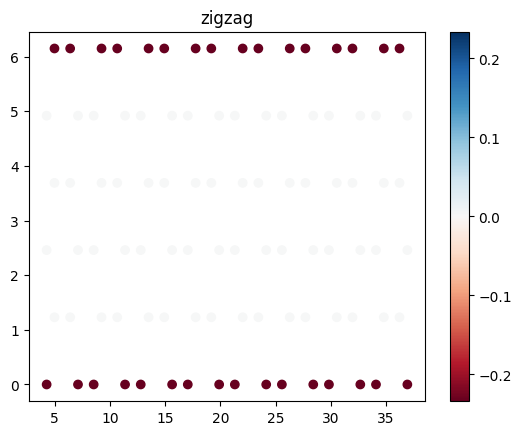

In [7]:
num_atoms = 4 * 4
ND = tbtse.na
NL = tbtse.na_down(0)
NR = tbtse.na_down(1)
idxL = slice(NL//2-num_atoms, NL//2+num_atoms, 1)
idxD = slice(ND//2-num_atoms, ND//2+num_atoms, 1)
idxR = slice(ND-NR//2-num_atoms, ND-NR//2+num_atoms, 1)
print(idxL, idxD, idxR)


xyz = tbtse.xyz

E = 0.0
kpts = [0., 0.5, 0.]
site0 = NL//2
site1 = ND-NR//2
coup0 = np.imag(GetSigma(e=E, elec=0, k=kpts))
coup1 = np.imag(GetSigma(e=E, elec=1, k=kpts))
print(coup1.shape)

vmax = np.max(np.abs([coup0, coup1]))
vmin = -vmax
cmap='RdBu'
fig, ax = plt.subplots()
ax.set_title(lab)
ax.scatter(x=xyz[idxL, 0], y=xyz[idxL, 1], label='left', c=np.diag(coup0)[idxL], vmin=vmin, vmax=vmax, cmap=cmap)
sc=ax.scatter(x=xyz[idxD, 0], y=xyz[idxD, 1], label='device', c=np.zeros(shape=(2*num_atoms)), vmin=vmin, vmax=vmax, cmap=cmap)
ax.scatter(x=xyz[idxR, 0], y=xyz[idxR, 1], label='Right', c=np.diag(coup1)[idxL], vmin=vmin, vmax=vmax, cmap=cmap)

fig.colorbar(sc)
# ax.axis('square')

slice(0, 40, 1) slice(40, 80, 1) slice(80, 120, 1)
120


warn:0: SileWarning:

tbtsencSileTBtrans requesting k-point [0.000, 0.500, 0.000] found [0.000, 0.000, 0.000]

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

warn:0: SileWarning:

tbtsencSileTBtrans requesting k-point [0.000, 0.500, 0.000] found [0.000, 0.000, 0.000]

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

warn:0: SileWarning:

tbtsencSileTBtrans requesting k-point [0.000, 0.500, 0.000] found [0.000, 0.000, 0.000]

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

warn:0: SileWarning:

tbtsencSileTBtrans requesting k-point [0.000, 0.500, 0.000] found [0.000, 0.000, 0.000]

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!



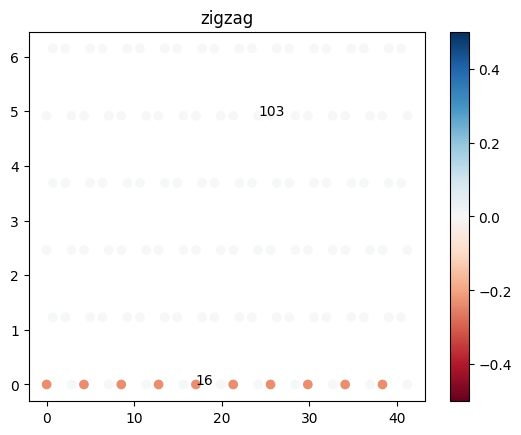

In [8]:
num_atoms = 4 * 5
ND = tbtse.na
NL = tbtse.na_down(0)
NR = tbtse.na_down(1)
idxL = slice(NL//2-num_atoms, NL//2+num_atoms, 1)
idxD = slice(ND//2-num_atoms, ND//2+num_atoms, 1)
idxR = slice(ND-NR//2-num_atoms, ND-NR//2+num_atoms, 1)
print(idxL, idxD, idxR)
print(ND)

xyz = tbtse.xyz

E = 0.0
kpts = [0., 0.5, 0.]
site0 = NL//2 -4
site1 = ND-NR//2 + 3
# site1 = ND-NR//2 +3
coup0 = np.imag(GetSigma(e=E, elec=0, k=kpts))
coup1 = np.imag(GetSigma(e=E, elec=1, k=kpts))

Broadening = np.zeros(shape=(ND, ND), dtype=np.complex128)
Broadening[idxL, idxL] += GetSigma(e=E, elec=0, k=kpts)
Broadening[idxR, idxR] += GetSigma(e=E, elec=1, k=kpts)

# vmax = np.max(np.abs([coup0, coup1]))
# vmin = -vmax
vmax = 0.5
vmin = -vmax
cmap='RdBu'
fig, ax = plt.subplots()
ax.set_title(lab)
# ax.scatter(x=xyz[idxL, 0], y=xyz[idxL, 1], label='left', c=coup0[idxL, site0], vmin=vmin, vmax=vmax, cmap=cmap)
# ax.scatter(x=xyz[idxD, 0], y=xyz[idxD, 1], label='device', c=np.zeros(shape=(2*num_atoms)), vmin=vmin, vmax=vmax, cmap=cmap)
# ax.scatter(x=xyz[idxR, 0], y=xyz[idxR, 1], label='Right', c=coup1[idxL, site0+3], vmin=vmin, vmax=vmax, cmap=cmap)
ax.scatter(x=xyz[:ND//2, 0], y=xyz[:ND//2, 1], c=np.imag(Broadening[:ND//2, site0]), vmin=vmin, vmax=vmax, cmap=cmap)
sc = ax.scatter(x=xyz[ND//2:, 0], y=xyz[ND//2:, 1], c=np.imag(Broadening[ND//2:, site1]), vmin=vmin, vmax=vmax, cmap=cmap)
fig.colorbar(sc)
for atom in [site0, site1]:
    ax.annotate(text=atom, xy=(xyz[atom, :2]))
    
# fig.colorbar(sc)
# ax.axis('square')

In [9]:
geom = tbtse.read_geometry()
geom.plot(axes='xy')

tbtse.k

array([[0.  , 0.  , 0.  ],
       [0.01, 0.  , 0.  ],
       [0.02, 0.  , 0.  ],
       [0.03, 0.  , 0.  ],
       [0.04, 0.  , 0.  ],
       [0.05, 0.  , 0.  ],
       [0.06, 0.  , 0.  ],
       [0.07, 0.  , 0.  ],
       [0.08, 0.  , 0.  ],
       [0.09, 0.  , 0.  ],
       [0.1 , 0.  , 0.  ],
       [0.11, 0.  , 0.  ],
       [0.12, 0.  , 0.  ],
       [0.13, 0.  , 0.  ],
       [0.14, 0.  , 0.  ],
       [0.15, 0.  , 0.  ],
       [0.16, 0.  , 0.  ],
       [0.17, 0.  , 0.  ],
       [0.18, 0.  , 0.  ],
       [0.19, 0.  , 0.  ],
       [0.2 , 0.  , 0.  ],
       [0.21, 0.  , 0.  ],
       [0.22, 0.  , 0.  ],
       [0.23, 0.  , 0.  ],
       [0.24, 0.  , 0.  ],
       [0.25, 0.  , 0.  ],
       [0.26, 0.  , 0.  ],
       [0.27, 0.  , 0.  ],
       [0.28, 0.  , 0.  ],
       [0.29, 0.  , 0.  ],
       [0.3 , 0.  , 0.  ],
       [0.31, 0.  , 0.  ],
       [0.32, 0.  , 0.  ],
       [0.33, 0.  , 0.  ],
       [0.34, 0.  , 0.  ],
       [0.35, 0.  , 0.  ],
       [0.36, 0.  , 0.  ],
 

In [10]:
# trunc = -1
# geom = tbtse.read_geometry()
# x,y,_ = geom.xyz[:trunc].T
# A, B, C = geom.cell[:2, :].T

# fig, ax = plt.subplots(figsize=(20,2))
# ax.scatter(x,y)
# UC_x, UC_y = np.array([A-A, A, A+B, B, B-B]).T
# ax.plot(UC_x, UC_y, color='g', lw=2)
# ax.axis('scaled')
# ax.set_xlim((A.min()- 10, A.max() -400))

In [11]:
path =  Path(f'./TBT-Nw{Nw}-{lab}')
Hfile = path / f'{lab}.TBT.SE.nc'
Hfile.exists()

True

In [12]:
H_dev = sisl.get_sile(Hfile)
H_dev.read_geometry().plot(axes='xy')

In [13]:
Nw = 10
Nl = 3
kind = "zigzag"

if kind == 'armchair':
    gr = sisl.geom.graphene(1.42, orthogonal=True).tile(Nw, 1).tile(Nl, 0)
elif kind == 'zigzag':
    gr = sisl.geom.graphene(1.42, orthogonal=True).tile(Nw, 0).tile(Nl,1)

style = [
    {'atoms':range(4*Nw), 'color':'red'},
    {'atoms':range(-4*Nw, 0), 'color':'blue'}
]
fig = gr.plot(axes='xy', atoms_style=style)
fig

In [14]:
view(gr.to.ase())

<Popen: returncode: None args: ['/home/bastian/projects/QTM-ML/.venv/bin/pyt...>

# Plotting conv for Siesta calcs

In [15]:
cwd = Path("./")
arm_dir = list(cwd.parent.glob("TBT-Nw*-armchair"))
zig_dir = list(cwd.parent.glob("TBT-Nw*-zigzag"))

def GetSE(file, E=0,
        elec=0,
        k=[0.0, 0.0, 0.0]):
    tmp = file.self_energy(elec=0, E=E, k=k, sort=True).data
    pvt = file.pivot(elec=elec, in_device=True, sort=True).reshape(-1, 1)
    no_d = file.na_d
    Sigma = np.zeros((no_d, no_d), dtype=np.complex128)
    Sigma[pvt, pvt.T] += tmp
    return Sigma


E = 0.
kpts = [0., 0., 0.]


nZ = []
nA = []
ZonL = []
ZonR = []
AonL = []
AonR = []
for zig in zig_dir:
    n = int(str(zig).split('-')[1][2:])
    nZ.append(n)
    
    seZ = sisl.io.get_sile(zig / 'zigzag.TBT.SE.nc')
    d = seZ.na_d // 2
    SEL = np.imag(GetSE(seZ, E=E, elec=0, k=kpts))
    SER = np.imag(GetSE(seZ, E=E, elec=1, k=kpts))
    ZonL.append(np.diag(SEL)[n])
    ZonR.append(np.diag(SER)[n+3])

for arm in arm_dir:
    n = int(str(arm).split('-')[1][2:])
    nA.append(n)
    seA= sisl.io.get_sile(arm / 'armchair.TBT.SE.nc')
    d = seZ.na_d // 2
    SEL = np.imag(GetSE(seA, E=E, elec=0, k=kpts))
    SER = np.imag(GetSE(seA, E=E, elec=1, k=kpts))
    AonL.append(np.diag(SEL)[n])
    AonR.append(np.diag(SER)[n+3])
    
    

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:



In [16]:
import matplotlib.font_manager as fm

# This scans the system for all available fonts Matplotlib can see
fonts = sorted(set([f.name for f in fm.fontManager.ttflist]))

# Check if 'Latin Modern' is in the list
latex_fonts = [f for f in fonts if "Latin" in f or "Modern" in f]
print("Found these LaTeX-style fonts:", latex_fonts)
print("is {} in the list : {}".format(target := "Latin Modern Roman", target in latex_fonts))

Found these LaTeX-style fonts: ['Latin Modern Math', 'Latin Modern Mono', 'Latin Modern Mono Caps', 'Latin Modern Mono Light', 'Latin Modern Mono Light Cond', 'Latin Modern Mono Prop', 'Latin Modern Mono Prop Light', 'Latin Modern Mono Slanted', 'Latin Modern Roman', 'Latin Modern Roman Caps', 'Latin Modern Roman Demi', 'Latin Modern Roman Dunhill', 'Latin Modern Roman Slanted', 'Latin Modern Roman Unslanted', 'Latin Modern Sans', 'Latin Modern Sans Demi Cond', 'Latin Modern Sans Quotation']
is Latin Modern Roman in the list : True


In [17]:
# import matplotlib as mpl
# import os
# import shutil

# # This deletes the font cache so matplotlib scans your system again
# cache_dir = mpl.get_cachedir()
# if os.path.exists(cache_dir):
#     shutil.rmtree(cache_dir)
#     print("Font cache cleared. Restart your kernel/script.")

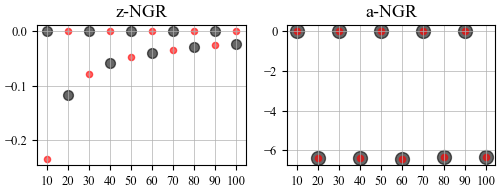

In [ ]:
fig, ax = thesis_fig(fraction=1, subplots=(1,2))
ax[0].set_title('z-NGR')
ax[0].scatter(nZ, ZonL, c='k', alpha=0.6, s=50)
ax[0].scatter(nZ, ZonR, c='r', alpha=0.6, s=20)
ax[0].set_xticks(nZ)
ax[0].grid()

ax[1].set_title('a-NGR')
ax[1].scatter(nA, AonL, c='k', alpha=0.6, s=100)
ax[1].scatter(nA, AonR, c='r', alpha=0.6, s=20)
ax[1].set_xticks(nA)
ax[1].grid()

fig.savefig('test-save-conv')



In [19]:
from matplotlib import rcParams
list(key for key in rcParams.keys() if key.startswith("font"))

['font.cursive',
 'font.family',
 'font.fantasy',
 'font.monospace',
 'font.sans-serif',
 'font.serif',
 'font.size',
 'font.stretch',
 'font.style',
 'font.variant',
 'font.weight']

# Coupling

In [20]:
E = 0.
kpts = [0., 0., 0.]

nZ = []
nA = []
ZcoupL = []
ZcoupR = []
AcoupL = []
AcoupR = []
for zig in zig_dir:
    n = int(str(zig).split('-')[1][2:])
    nZ.append(n)
    
    seZ = sisl.io.get_sile(zig / 'zigzag.TBT.SE.nc')
    d = seZ.na_d // 2
    SEL = np.imag(GetSE(seZ, E=E, elec=0, k=kpts))
    SER = np.imag(GetSE(seZ, E=E, elec=1, k=kpts))
    ZcoupL.append(SEL[n, slice(n,n*5, 3)])
    ZcoupR.append(SER[n+3, slice(n+3,(n+3)*5, 3)])

for arm in arm_dir:
    n = int(str(arm).split('-')[1][2:])
    nA.append(n)
    seA= sisl.io.get_sile(arm / 'armchair.TBT.SE.nc')
    d = seZ.na_d // 2
    SEL = np.imag(GetSE(seA, E=E, elec=0, k=kpts))
    SER = np.imag(GetSE(seA, E=E, elec=1, k=kpts))
    
    AcoupL.append(SEL[n, slice(n,n*5, 3)])
    AcoupR.append(SER[n+3, slice(n+3,(n+3)*5, 3)])
    
    

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:

tbtsencSileTBtrans requesting energy 0.00000 eV, found 0.00500 eV as the closest energy!

info:0: SislInfo:



[array([-3.91713642e-02,  2.45918527e-05,  0.00000000e+00,  0.00000000e+00,
       -3.90343629e-02,  2.55302948e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89975049e-02,  2.59213357e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89763825e-02,  2.60393408e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89621556e-02,  2.59806893e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89519520e-02,  2.57973388e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89445089e-02,  2.55233263e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89391705e-02,  2.51837937e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89355607e-02,  2.47989828e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89334708e-02,  2.43863324e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89327817e-02,  2.39617602e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89334708e-02,  2.35405769e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89355607e-02,  2.31382637e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89391705e-02, 

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (10,) + inhomogeneous part.

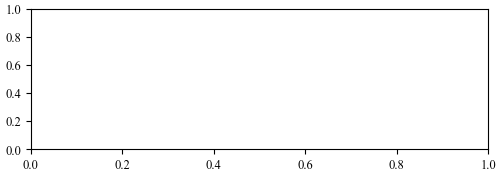

In [21]:
fig, ax = plt.subplots()
print(ZcoupL)

ax.scatter(nZ, ZcoupL, c='k')
ax.scatter(nZ, ZcoupR, c='r')